# 다음 영화 리뷰의 키워드 분석 

1. 데이터 준비 (로딩)
2. 텍스트 전처리 (토큰화, 불용어 제거)
3. 빈도수 분석 (Counter)
   
* 시각화 1 : 수평 막대그래프
* 시각화 2 : 워드클라우드
  
  

In [5]:
# 데이터 준비 (로딩)
data_filename = './data/daum_movie_review.csv'

import pandas as pd 
movie_df = pd.read_csv(data_filename)
#movie_df.head()
review_list = list(movie_df.review)
review_list[:10]

['돈 들인건 티가 나지만 보는 내내 하품만',
 '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
 '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
 '이 정도면 볼만하다고 할 수 있음!',
 '재미있다',
 '나는 재밌게 봄',
 '0.5점은 줄 수 없냐?',
 '헐..다 죽었어....나중에 앤트맨 보다가도 깜놀...',
 '충격 결말',
 '응집력']

 # 2.텍스트 전처리
   * 텍스트를 나눈다 (토큰화)
   * 쓸데없는 단어를 제거한다
   * 중요한 단어만 남긴다


In [7]:
# 텍스트 전처리
from konlpy.tag import Okt

okt = Okt(jvmpath=r"C:\Program Files\Java\jdk-17\bin\server\jvm.dll")

all_text = " ".join(review_list)
tokens = okt.nouns(all_text)
print(tokens[:20])

['돈', '티', '나', '내내', '하품', '몰입', '생각', '내', '전투', '참여', '듯', '손', '땀', '이남', '이전', '작품', '더', '스케일', '전국', '맛집']


In [8]:
#텍스트 전처리
stopwords = ['영화', '정말', '너무', '진짜', '이거', '그거']

filtered = [word for word in tokens if word not in stopwords and len(word) > 1]

print(filtered[:20])

['내내', '하품', '몰입', '생각', '전투', '참여', '이남', '이전', '작품', '스케일', '전국', '맛집', '음식', '모두', '그릇', '느낌', '다음', '작품', '정도', '나중']


# 3.빈도수 분석

In [9]:
from collections import Counter

count = Counter(filtered)
print(count.most_common(10))

[('연기', 1293), ('감동', 1223), ('생각', 1027), ('배우', 847), ('사람', 819), ('스토리', 815), ('눈물', 737), ('보고', 702), ('최고', 682), ('재미', 641)]


In [22]:
#수평 막대그래프
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.barh(words, freqs)
plt.title("키워드 빈도수")
plt.xlabel("빈도")
plt.ylabel("키워드")

plt.show()

NameError: name 'freqs' is not defined

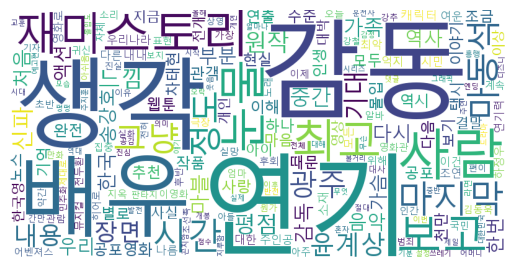

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 워드클라우드 생성
wc = WordCloud(
    font_path='C:/Windows/Fonts/malgun.ttf',
    background_color='white',
    width=800,
    height=400
)

cloud = wc.generate_from_frequencies(count)

# 출력
plt.imshow(cloud)
plt.axis('off')
plt.show()